In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    "../data/cleaned/datapulse_sales_cleaned.csv"
)

df["order_date"] = pd.to_datetime(df["order_date"])

df.head()

,order_id,order_date,customer_id,product,category,region,quantity,unit_price,discount,payment_method,returned,gross_sales,discount_amount,net_sales,year,month,month_name,day_name
0,O00001,2025-01-01 00:00:00.000000000,C0017,Headphones,Accessories,North,3,2500,0.00,Credit Card,No,7500,0.0,7500.0,2025,1,January,Wednesday
1,O00002,2025-01-01 02:36:59.483896779,C0056,Monitor,Electronics,East,4,15000,0.00,Credit Card,No,60000,0.0,60000.0,2025,1,January,Wednesday
2,O00003,2025-01-01 05:13:58.967793558,C0182,Laptop,Electronics,North,2,65000,0.05,Cash,No,130000,6500.0,123500.0,2025,1,January,Wednesday
3,O00004,2025-01-01 07:50:58.451690338,C0144,Laptop,Electronics,East,3,65000,0.10,Debit Card,No,195000,19500.0,175500.0,2025,1,January,Wednesday
4,O00005,2025-01-01 10:27:57.935587117,C0319,Laptop,Electronics,West,1,65000,0.00,Debit Card,No,65000,0.0,65000.0,2025,1,January,Wednesday


In [4]:
# Creating DataPulse's core KPIs 
total_revenue = df["net_sales"].sum()

total_orders = df["order_id"].nunique()

total_customers = df["customer_id"].nunique()

average_order_value = (
    total_revenue / total_orders
)

total_quantity = df["quantity"].sum()

return_rate = (
    df["returned"].eq("Yes").mean() * 100
)

In [5]:
print("===== DATAPULSE KPI SUMMARY =====")

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")
print(f"Units Sold: {total_quantity:,}")
print(f"Return Rate: {return_rate:.2f}%")

===== DATAPULSE KPI SUMMARY =====
Total Revenue: ₹279,094,300.00
Total Orders: 5,000
Total Customers: 500
Average Order Value: ₹55,818.86
Units Sold: 14,951
Return Rate: 7.68%


In [6]:
# Creating a KPI DataFrame
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Average Order Value",
        "Units Sold",
        "Return Rate"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_customers,
        average_order_value,
        total_quantity,
        return_rate
    ]
})

kpi_summary

,Metric,Value
0,Total Revenue,2.790943e+08
1,Total Orders,5.000000e+03
2,Total Customers,5.000000e+02
3,Average Order Value,5.581886e+04
4,Units Sold,1.495100e+04
5,Return Rate,7.680000e+00


In [7]:
# Category performance
category_analysis = (
    df.groupby("category")
      .agg(
          Revenue=("net_sales", "sum"),
          Orders=("order_id", "nunique"),
          Units=("quantity", "sum"),
          AOV=("net_sales", "mean")
      )
      .sort_values("Revenue", ascending=False)
)

category_analysis

,Revenue,Orders,Units,AOV
category,,,,
Electronics,263947000.0,2541,7580,103875.245966
Accessories,15147300.0,2459,7371,6159.943066


In [8]:
# category contribution
category_analysis["Revenue_Contribution"] = (
    category_analysis["Revenue"]
    / total_revenue
    * 100
)

In [9]:
category_analysis

,Revenue,Orders,Units,AOV,Revenue_Contribution
category,,,,,
Electronics,263947000.0,2541,7580,103875.245966,94.572695
Accessories,15147300.0,2459,7371,6159.943066,5.427305


In [10]:
# Round it:
category_analysis["Revenue_Contribution"] = (
    category_analysis["Revenue_Contribution"]
    .round(2)
)
category_analysis


,Revenue,Orders,Units,AOV,Revenue_Contribution
category,,,,,
Electronics,263947000.0,2541,7580,103875.245966,94.57
Accessories,15147300.0,2459,7371,6159.943066,5.43


In [11]:
# transform()
df["Category_Revenue"] = (
    df.groupby("category")["net_sales"]
      .transform("sum")
)
df[
    [
        "product",
        "category",
        "net_sales",
        "Category_Revenue"
    ]
].head(10)

,product,category,net_sales,Category_Revenue
0,Headphones,Accessories,7500.0,15147300.0
1,Monitor,Electronics,60000.0,263947000.0
2,Laptop,Electronics,123500.0,263947000.0
3,Laptop,Electronics,175500.0,263947000.0
4,Laptop,Electronics,65000.0,263947000.0
5,Keyboard,Accessories,3800.0,15147300.0
6,Smartphone,Electronics,40000.0,263947000.0
7,Mouse,Accessories,3800.0,15147300.0
8,Laptop,Electronics,61750.0,263947000.0
9,Monitor,Electronics,75000.0,263947000.0


In [12]:
# Regional performance
region_analysis = (
    df.groupby("region")
      .agg(
          Revenue=("net_sales", "sum"),
          Orders=("order_id", "nunique"),
          Customers=("customer_id", "nunique"),
          AOV=("net_sales", "mean")
      )
      .sort_values("Revenue", ascending=False)
)

In [13]:
region_analysis["Revenue_Contribution"] = (
    region_analysis["Revenue"]
    / total_revenue
    * 100
).round(2)

In [14]:
region_analysis

,Revenue,Orders,Customers,AOV,Revenue_Contribution
region,,,,,
East,72130300.0,1265,457,57020.000000,25.84
South,69978440.0,1274,463,54928.131868,25.07
West,69370665.0,1227,448,56536.809291,24.86
North,67614895.0,1234,459,54793.269854,24.23


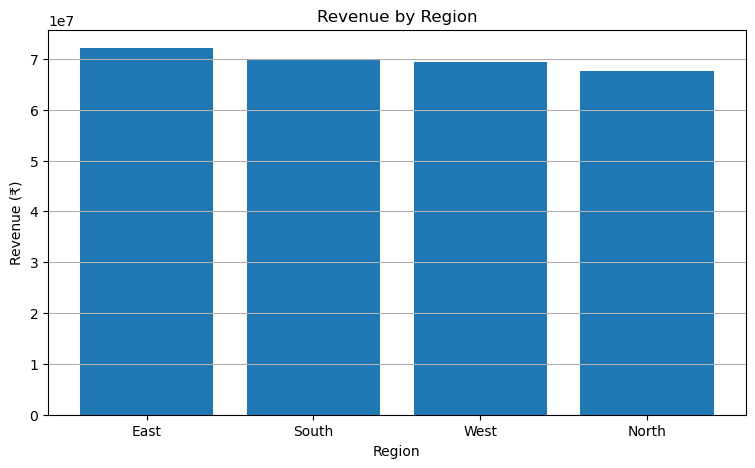

In [15]:
plt.figure(figsize=(9, 5))

plt.bar(
    region_analysis.index,
    region_analysis["Revenue"]
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue (₹)")

plt.grid(axis="y")

plt.show()

In [17]:
# Rank products
product_analysis = (
    df.groupby("product")
      .agg(
          Revenue=("net_sales", "sum"),
          Orders=("order_id", "nunique"),
          Units=("quantity", "sum"),
          AOV=("net_sales", "mean")
      )
      .sort_values("Revenue", ascending=False)
)
product_analysis

,Revenue,Orders,Units,AOV
product,,,,
Laptop,115261250.0,639,1917,180377.543036
Smartphone,71852000.0,649,1944,110711.864407
Tablet,50097000.0,602,1791,83217.607973
Monitor,26736750.0,651,1928,41070.276498
Webcam,6120625.0,616,1894,9936.079545
Headphones,4321375.0,633,1873,6826.816746
Keyboard,3398100.0,612,1835,5552.450980
Mouse,1307200.0,598,1769,2185.953177


In [18]:
# Top 5 products
top_5_products = (
    product_analysis
    .head(5)
)

top_5_products

,Revenue,Orders,Units,AOV
product,,,,
Laptop,115261250.0,639,1917,180377.543036
Smartphone,71852000.0,649,1944,110711.864407
Tablet,50097000.0,602,1791,83217.607973
Monitor,26736750.0,651,1928,41070.276498
Webcam,6120625.0,616,1894,9936.079545


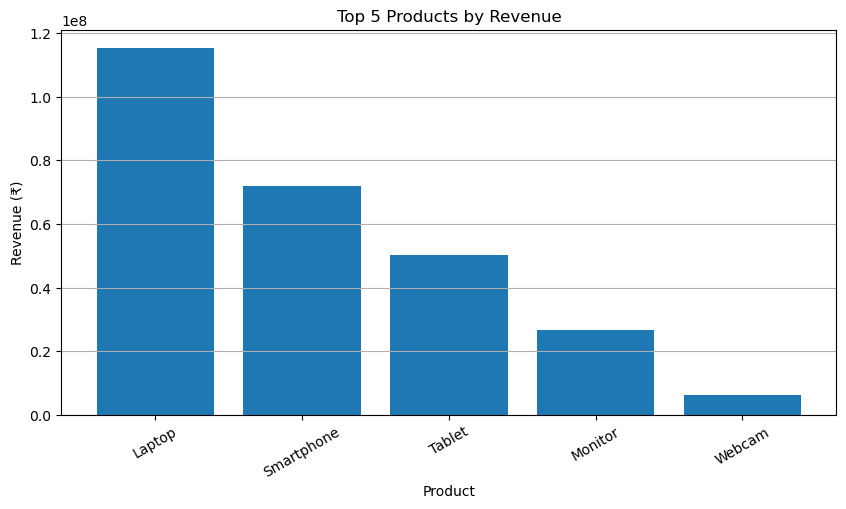

In [19]:
plt.figure(figsize=(10, 5))

plt.bar(
    top_5_products.index,
    top_5_products["Revenue"]
)

plt.title("Top 5 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=30)
plt.grid(axis="y")

plt.show()

In [20]:
# Monthly KPI table
monthly_kpis = (
    df.set_index("order_date")
      .resample("ME")
      .agg(
          Revenue=("net_sales", "sum"),
          Orders=("order_id", "nunique"),
          Customers=("customer_id", "nunique"),
          Units=("quantity", "sum")
      )
)

In [21]:
monthly_kpis["AOV"] = (
    monthly_kpis["Revenue"]
    / monthly_kpis["Orders"]
)

In [22]:
monthly_kpis["MoM_Growth"] = (
    monthly_kpis["Revenue"]
    .pct_change() * 100
)

In [23]:
monthly_kpis = monthly_kpis.round(2)

monthly_kpis

,Revenue,Orders,Customers,Units,AOV,MoM_Growth
order_date,,,,,,
2025-01-31,15486360.0,285,212,892,54338.11,NaN
2025-02-28,15545610.0,257,205,776,60488.75,0.38
2025-03-31,15615460.0,284,221,877,54984.01,0.45
2025-04-30,13693690.0,275,218,831,49795.24,-12.31
2025-05-31,17074470.0,285,211,875,59910.42,24.69
2025-06-30,14767605.0,275,214,828,53700.38,-13.51
2025-07-31,15311520.0,284,217,818,53913.80,3.68
2025-08-31,16063435.0,284,217,840,56561.39,4.91
2025-09-30,15232320.0,276,214,797,55189.57,-5.17


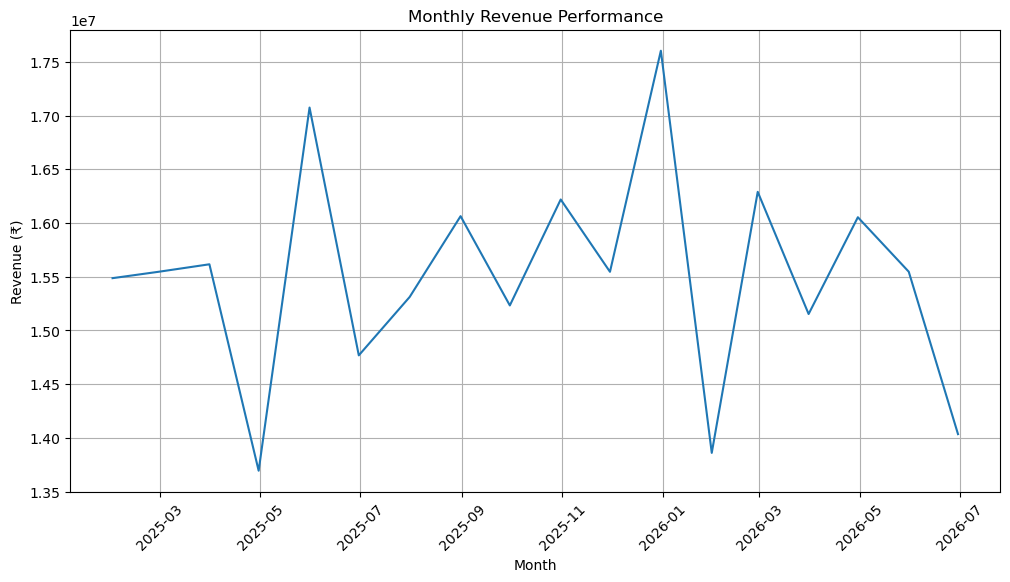

In [24]:
# Revenue vs Orders
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    monthly_kpis.index,
    monthly_kpis["Revenue"]
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue (₹)")

ax1.tick_params(axis="x", rotation=45)

plt.title("Monthly Revenue Performance")

plt.grid()

plt.show()

# Day 9 Insights...
#  Day 9 — KPI & Performance Insights

## Overall Business Performance

- Total Revenue: ₹279,094,300
- Total Orders: 5000
- Total Customers: 500
- Average Order Value: ₹55,818.86
- Units Sold: 14,951
- Return Rate: 7.68%

## Category Performance

### Top Category
Electronics

Revenue contribution:
94.57%

### Key Observation
Electronics is the dominant revenue-generating category, contributing 94.57% of total revenue. Its AOV of ₹103,875 is substantially higher than Accessories, indicating that high-value electronic products are the primary drivers of business revenue.

## Regional Performance

### Top Region
East

Revenue contribution:
25.48%

### AOV Observation
The region with the highest AOV was East, with an AOV of approximately ₹57,020.

This indicates that customers in the East region generate slightly higher-value orders on average, making it the strongest region both in revenue contribution and order value.

## Product Performance

### Top Product
Laptop

### Lowest Revenue Product
Mouse

### Key Observation
Laptop is the strongest product, generating more revenue than any other product, while Mouse has the lowest revenue. The results show a strong concentration of revenue around high-value products such as Laptops, Smartphones and Tablets.

## Monthly Performance

The strongest month was December 2025, with revenue of ₹17,603,590.

The weakest month was April 2025, with revenue of ₹13,693,690.

The monthly performance suggests significant fluctuations in revenue throughout the period, with strong growth in May and December but notable declines in April, June 2025 and January 2026. This indicates that sales performance is not completely stable and may be influenced by seasonal or promotional factors.

## Overall Business Insight

DataPulse's revenue is heavily dependent on high-value Electronics products, particularly Laptops. Electronics alone contributes 94.57% of total revenue, while the East region leads regional revenue at 25.84%. Although the business generated ₹279.09 million in revenue, the 7.68% return rate and monthly revenue fluctuations highlight areas where customer retention, product quality and sales consistency could be improved.

In [25]:
category_analysis.to_csv(
    "../data/processed/category_performance.csv"
)

In [26]:
region_analysis.to_csv(
    "../data/processed/region_performance.csv"
)

In [27]:
product_analysis.to_csv(
    "../data/processed/product_performance.csv"
)

In [28]:
monthly_kpis.to_csv(
    "../data/processed/monthly_kpis.csv"
)